# Question 6 : PCA + classification

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import hashlib

In [32]:
def _add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("\n" + "="*50 + "\n")

In [33]:
username = "siddarth.g"
# seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
seed = 42
np.random.seed(seed)
print("Seed value : ", seed)
print_separator()

Seed value :  42




In [34]:
class PCA:

    def __init__(self, n_components):
        """
        Initialize PCA with specified number of components.
        
        Parameters:
        n_components (int): Number of principal components to keep
        """
        self.n_components = n_components
        self.components = None # Matrix with columns denoting eigen vectors, is of size (n_features, n_components)
        self.mean = None
        self.explained_variance_ratio = None # Contains an array of first n_components variance values divided by the cumulative total variance value
    
    def fit(self, X):
        """
        Fit PCA on the input data.
        
        Parameters:
        X (np.ndarray): Input data matrix of shape (n_samples, n_features)
        
        Returns:
        self: Fitted PCA object
        """
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean # Is of size (n_samples, n_features), Broadcasting
        
        # Compute covariance matrix
        cov_matrix = np.cov(X_centered.T) # Treat columns as features, not the default rows
        
        # Compute eigenvalues and eigenvectors
        # eigenvectors is a matrix with the columns as principal components
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) # eigh for symmetric matrices is more efficient
        
        # Sort by eigenvalues in descending order
        idx = np.argsort(-eigenvalues)
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # Store principal components
        self.components = eigenvectors[:, :self.n_components]
        
        # Calculate explained variance ratio
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio = eigenvalues[:self.n_components] / total_variance
        
        return self
    
    def transform(self, X):
        """
        Transform data to lower dimensional space.
        
        Parameters:
        X (np.ndarray): Input data matrix of shape (n_samples, n_features)
        
        Returns:
        np.ndarray: Transformed data of shape (n_samples, n_components)
        """
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)
    
    def fit_transform(self, X):
        """
        Fit PCA and transform data in one step.
        
        Parameters:
        X (np.ndarray): Input data matrix of shape (n_samples, n_features)
        
        Returns:
        np.ndarray: Transformed data of shape (n_samples, n_components)
        """
        return self.fit(X).transform(X)
    
    def checkPCA(self):
        """
        Check if PCA reduces dimensionality appropriately.
        
        Returns:
        bool: True if n_components < original dimensions, False otherwise
        """
        if self.components is None:
            print("PCA has not been fitted yet.")
            return False
        
        original_dims = self.components.shape[0]
        reduced_dims = self.components.shape[1]
        
        print(f"Original dimensions: {original_dims}")
        print(f"Reduced dimensions: {reduced_dims}")
        print(f"Dimensionality reduced: {reduced_dims < original_dims}")
        
        return reduced_dims < original_dims

In [35]:
def load_dataset(random_seed=42):
    """
    Load MNIST digits dataset and split into training and testing sets.
    
    Returns:
    tuple: (X_train, X_test, y_train, y_test) arrays
    """
    # Load the 8x8 MNIST digits dataset
    digits = load_digits()
    X, y = digits.data, digits.target

    # Print dataset info
    print(f"Dataset shape: {X.shape}, Labels shape: {y.shape}")
    print("Printing first image")
    plt.imshow(X[0].reshape(8, 8), cmap='gray')
    plt.title(f"Label: {y[0]}")
    _add_username("siddarth.g")
    plt.show()

    # Split into training and testing sets (80-20 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

    return X_train, X_test, y_train, y_test

In [36]:
def apply_pca_reduction(X_train, X_test, n_components_list):
    """
    Apply PCA dimensionality reduction for different numbers of components.
    
    Parameters:
    X_train (array): Training data
    X_test (array): Testing data  
    n_components_list (list): List of component numbers to test
    
    Returns:
    dict: Dictionary with transformed datasets for each n_components
    """
    pca_results = {}
    
    for n_comp in n_components_list:
        print(f"Applying PCA with {n_comp} components...")

        pca = PCA(n_components=n_comp)
        pca.fit(X_train)
        
        # Transform both training and testing data
        X_train_pca = pca.transform(X_train)
        X_test_pca = pca.transform(X_test)
        
        pca_results[n_comp] = {
            'X_train_pca': X_train_pca,
            'X_test_pca': X_test_pca
        }
    
    return pca_results

In [37]:
def train_and_evaluate_knn(pca_results, y_train, y_test, k_values, n_components_list):
    """
    Train KNN classifiers on PCA-transformed data and evaluate performance.
    
    Parameters:
    pca_results (dict): Dictionary containing PCA-transformed datasets
    y_train (array): Training labels
    y_test (array): Testing labels
    k_values (list): List of k values for KNN
    n_components_list (list): List of component numbers tested
    
    Returns:
    dict: Dictionary containing accuracy results for each combination
    """
    results = {} # Dictionary of dictionaries
    
    for n_comp in n_components_list:
        results[n_comp] = {}
        X_train_pca = pca_results[n_comp]['X_train_pca']
        X_test_pca = pca_results[n_comp]['X_test_pca']
        
        for k in k_values:
            print(f"Training KNN with k={k} on {n_comp} components...")
            
            # Initialize and train KNN classifier
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_pca, y_train)
            
            # Make predictions on test data
            y_pred = knn.predict(X_test_pca)
            
            # Calculate and store accuracy
            accuracy = accuracy_score(y_test, y_pred)
            results[n_comp][k] = accuracy
            
            print(f"  Accuracy: {accuracy:.4f}")
    
    return results

In [38]:
def visualize_results(results, k_values, n_components_list):
    """
    Create visualization showing relationship between components and accuracy.
    
    Parameters:
    results (dict): Dictionary containing accuracy results
    k_values (list): List of k values for KNN
    n_components_list (list): List of component numbers tested
    """
    plt.figure(figsize=(12, 8))
    
    # Plot accuracy vs number of components for each k value
    for k in k_values:
        accuracies = [results[n_comp][k] for n_comp in n_components_list]
        plt.plot(n_components_list, accuracies, marker='o', linewidth=2, 
                label=f'k={k}', markersize=6)
    
    plt.xlabel('Number of Principal Components', fontsize=12)
    plt.ylabel('Classification Accuracy', fontsize=12)
    plt.title('KNN Accuracy vs Number of PCs', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(n_components_list)
    plt.tight_layout()
    _add_username("siddarth.g")
    plt.show()

In [39]:
def analyze_results(results, k_values, n_components_list):
    """
    Analyze and discuss the findings from the experiment.
    
    Parameters:
    results (dict): Dictionary containing accuracy results
    k_values (list): List of k values for KNN  
    n_components_list (list): List of component numbers tested
    """
    print_separator()
    print("ANALYSIS OF RESULTS")
    print_separator()

    for k in k_values:
        accuracies = [results[n_comp][k] for n_comp in n_components_list]
        print(f"  k={k}: Accuracy range from {min(accuracies):.4f} to {max(accuracies):.4f}")
    
    # Find best performing combination
    best_accuracy = 0
    best_k = 0
    best_n_comp = 0
    
    for n_comp in n_components_list:
        for k in k_values:
            if results[n_comp][k] > best_accuracy:
                best_accuracy = results[n_comp][k]
                best_k = k
                best_n_comp = n_comp
    
    print(f"Best performance: {best_accuracy:.4f} accuracy with k={best_k} and {best_n_comp} components")

PCA + KNN Classification on MNIST Digits


Loading and preparing data...
Dataset shape: (1797, 64), Labels shape: (1797,)
Printing first image


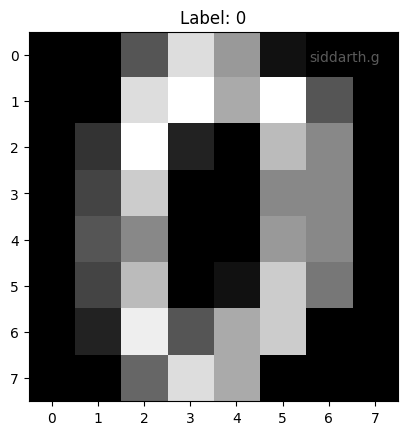

Applying PCA dimensionality reduction...
Applying PCA with 2 components...
Applying PCA with 5 components...
Applying PCA with 10 components...
Applying PCA with 20 components...
Applying PCA with 30 components...
Applying PCA with 40 components...
Applying PCA with 50 components...
Applying PCA with 64 components...
Training and evaluating KNN classifiers...
Training KNN with k=3 on 2 components...
  Accuracy: 0.6000
Training KNN with k=5 on 2 components...
  Accuracy: 0.6222
Training KNN with k=25 on 2 components...
  Accuracy: 0.6722
Training KNN with k=50 on 2 components...
  Accuracy: 0.6611
Training KNN with k=100 on 2 components...
  Accuracy: 0.6556
Training KNN with k=3 on 5 components...
  Accuracy: 0.9361
Training KNN with k=5 on 5 components...
  Accuracy: 0.9389
Training KNN with k=25 on 5 components...
  Accuracy: 0.9194
Training KNN with k=50 on 5 components...
  Accuracy: 0.9056
Training KNN with k=100 on 5 components...
  Accuracy: 0.8611
Training KNN with k=3 on 10 co

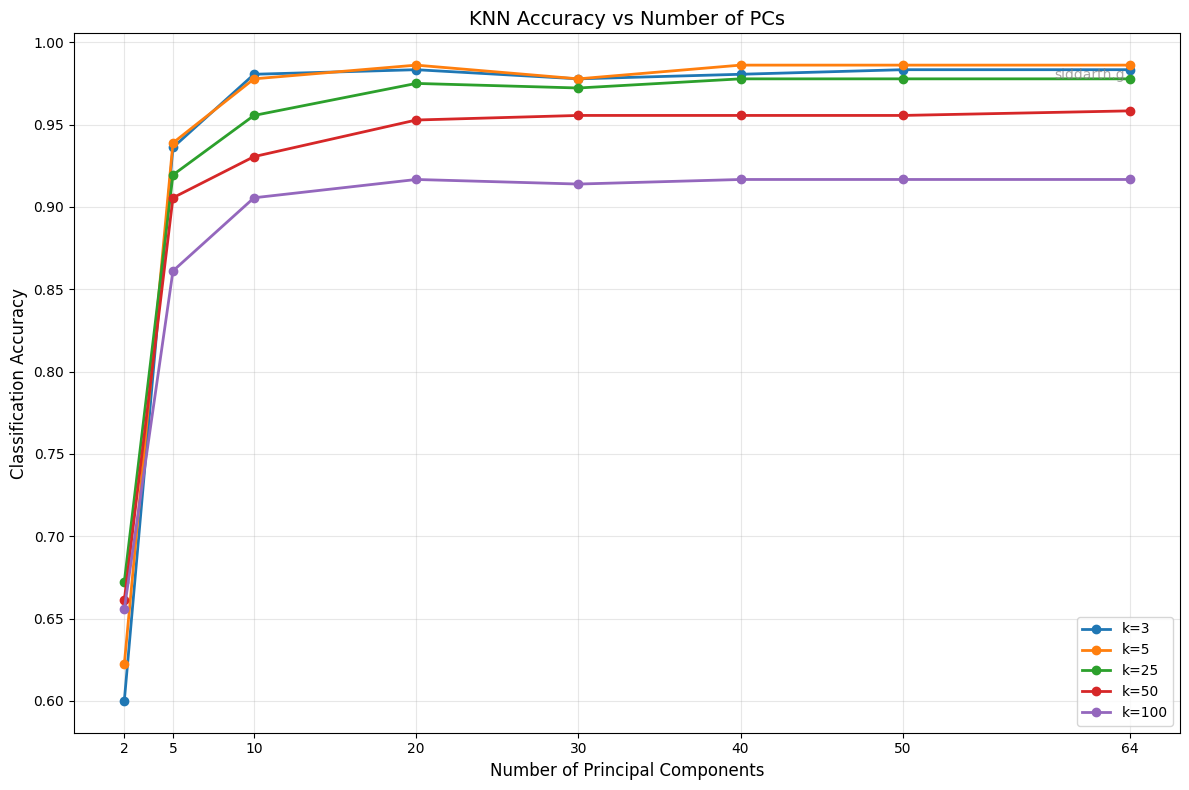



ANALYSIS OF RESULTS


  k=3: Accuracy range from 0.6000 to 0.9833
  k=5: Accuracy range from 0.6222 to 0.9861
  k=25: Accuracy range from 0.6722 to 0.9778
  k=50: Accuracy range from 0.6611 to 0.9583
  k=100: Accuracy range from 0.6556 to 0.9167
Best performance: 0.9861 accuracy with k=5 and 20 components




In [40]:
print("PCA + KNN Classification on MNIST Digits")
print_separator()

# Define parameters
n_components_list = [2, 5, 10, 20, 30, 40, 50, 64]
k_values = [3, 5, 25, 50, 100]

print("Loading and preparing data...")
X_train, X_test, y_train, y_test = load_dataset()

print("Applying PCA dimensionality reduction...")
pca_results = apply_pca_reduction(X_train, X_test, n_components_list)

print("Training and evaluating KNN classifiers...")
results = train_and_evaluate_knn(pca_results, y_train, y_test, k_values, n_components_list)

print("Creating visualization...")
visualize_results(results, k_values, n_components_list)

analyze_results(results, k_values, n_components_list)

print_separator()